# Part I: Exploratory Data Analysis
## US Airlines On-Time Performance — 2025 Departure & Arrival Delay Analysis


## Introduction

This notebook explores the Bureau of Transportation Statistics **Reporting Carrier On-Time Performance Data** for 2025 (~7 million flights). The analysis focuses on understanding what drives flight delays, both at departure and arrival, and how delays accumulate or dissipate over the course of a flight.

**Three guiding questions:**
1. **Q1 (Departure):** What factors most significantly influence flight departure delays?
2. **Q2 (Arrival):** What factors most significantly influence flight arrival delays?
3. **Q3 (Comparison):** How do the factors affecting departure delays differ from those affecting arrival delays?

This framing traces how delays accumulate (or get resolved) over the course of a flight. Departure delays reflect conditions at the origin (weather, airline operations, air traffic). Arrival delays reflect conditions at the destination plus any delays that accumulated en route. Comparing the two reveals where delays are introduced versus where they are mitigated.


## Step 0: Setup and Data Loading


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from zipfile import ZipFile
import warnings

warnings.simplefilter('ignore')

sns.set_style('whitegrid')
sns.set_context('notebook', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


### Load dataset (selected columns only to manage memory)

The raw 2025 BTS monthly ZIP files are committed under `data/raw/` with Git LFS. This notebook loads the selected analysis columns directly from `data/raw/`, or from `data/processed/combined_2025.csv` if that optional local cache exists.


In [ ]:
cols = ['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate', 'IATA_CODE_Reporting_Airline', 'Origin', 'OriginCityName', 'OriginState', 'Dest', 'DestCityName', 'DestState', 'CRSDepTime', 'DepTime', 'DepDelay', 'DepDelayMinutes', 'DepDel15', 'DepartureDelayGroups', 'DepTimeBlk', 'CRSArrTime', 'ArrTime', 'ArrDelay', 'ArrDelayMinutes', 'ArrDel15', 'ArrivalDelayGroups', 'ArrTimeBlk', 'Cancelled', 'CancellationCode', 'Diverted', 'ActualElapsedTime', 'AirTime', 'Flights', 'Distance', 'DistanceGroup', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']

DATA_DIR = Path('data/raw')
PROCESSED_DATA = Path('data/processed/combined_2025.csv')
ZIP_PATTERN = 'On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2025_*.zip'


def month_number(path):
    return int(path.stem.rsplit('_', 1)[-1])


def read_monthly_zip(zip_path, columns):
    with ZipFile(zip_path) as archive:
        csv_name = next(name for name in archive.namelist() if name.lower().endswith('.csv'))
        with archive.open(csv_name) as csv_file:
            return pd.read_csv(csv_file, usecols=columns, encoding='latin-1', low_memory=False)


if PROCESSED_DATA.exists():
    df = pd.read_csv(PROCESSED_DATA, usecols=cols, encoding='latin-1', low_memory=False)
    data_source = 'processed local cache'
else:
    zip_files = sorted(DATA_DIR.glob(ZIP_PATTERN), key=month_number)
    if len(zip_files) != 12:
        raise FileNotFoundError(
            'Expected 12 monthly 2025 BTS ZIP files in data/raw/. '
            'Copy or download them from BTS.'
        )
    df = pd.concat((read_monthly_zip(path, cols) for path in zip_files), ignore_index=True)
    data_source = 'monthly ZIP files in data/raw'

print(f"Source: {data_source}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Source: processed local cache
Shape: 7,001,619 rows x 39 columns


,Year,Month,DayofMonth,DayOfWeek,FlightDate,IATA_CODE_Reporting_Airline,Origin,OriginCityName,OriginState,Dest,...,ActualElapsedTime,AirTime,Flights,Distance,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2025,1,1,3,2025-01-01,AA,JFK,"New York, NY",NY,LAX,...,377.0,345.0,1.0,2475.0,10,NaN,NaN,NaN,NaN,NaN
1,2025,1,2,4,2025-01-02,AA,JFK,"New York, NY",NY,LAX,...,390.0,353.0,1.0,2475.0,10,NaN,NaN,NaN,NaN,NaN
2,2025,1,3,5,2025-01-03,AA,JFK,"New York, NY",NY,LAX,...,371.0,347.0,1.0,2475.0,10,NaN,NaN,NaN,NaN,NaN
3,2025,1,4,6,2025-01-04,AA,JFK,"New York, NY",NY,LAX,...,383.0,349.0,1.0,2475.0,10,NaN,NaN,NaN,NaN,NaN
4,2025,1,5,7,2025-01-05,AA,JFK,"New York, NY",NY,LAX,...,378.0,347.0,1.0,2475.0,10,NaN,NaN,NaN,NaN,NaN


## Step 1: Preliminary Wrangling


### What is the structure of the dataset?


In [26]:
print('--- Shape ---')
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print('\n--- Column dtypes ---')
print(df.dtypes)

print('\n--- Missing values per column ---')
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

print(f"\nTotal missing: {df.isnull().sum().sum():,}")


--- Shape ---
Rows: 7,001,619
Columns: 39

--- Column dtypes ---
Year                             int64
Month                            int64
DayofMonth                       int64
DayOfWeek                        int64
FlightDate                         str
IATA_CODE_Reporting_Airline        str
Origin                             str
OriginCityName                     str
OriginState                        str
Dest                               str
DestCityName                       str
DestState                          str
CRSDepTime                       int64
DepTime                        float64
DepDelay                       float64
DepDelayMinutes                float64
DepDel15                       float64
DepartureDelayGroups           float64
DepTimeBlk                         str
CRSArrTime                       int64
ArrTime                        float64
ArrDelay                       float64
ArrDelayMinutes                float64
ArrDel15                       float64

### What are the main features of interest?

The key features for this analysis are:

| Column(s) | Meaning |
|---|---|
| `DepDelay`, `ArrDelay` | Minutes early or late compared with scheduled departure/arrival; positive values mean late and negative values mean early. |
| `CarrierDelay`, `WeatherDelay`, `NASDelay`, `SecurityDelay`, `LateAircraftDelay` | Delay minutes attributed to airline operations, significant weather, national airspace or airport conditions, security events, or late inbound aircraft. |
| `Cancelled`, `Diverted` | Flight status flags; 1 means yes and 0 means no. |
| `Distance` | Flight distance in miles. |
| `IATA_CODE_Reporting_Airline`, `Origin`, `Dest` | Reporting airline, origin airport, and destination airport codes. |

**Critical note:** In this dataset, `NaN` in delay columns (DepDelay, ArrDelay, etc.) does **not** mean missing data — it means the flight was on time (0 delay). We must convert these to 0 for analysis.


### Supporting features

Features that help explain delay patterns:
- **Time features:** Month, DayOfWeek, DayofMonth, FlightDate
- **Time-of-day bins:** DepTimeBlk, ArrTimeBlk (pre-binned into 1-hour windows)
- **Airline:** IATA_CODE_Reporting_Airline (AA, DL, UA, etc.)
- **Route:** Origin, Dest, OriginState, DestState
- **Distance:** Distance, DistanceGroup
- **Delay causes:** CarrierDelay, WeatherDelay, NASDelay, SecurityDelay, LateAircraftDelay


### Data cleaning and feature engineering


In [27]:
# Convert NaN delays to 0 (on-time flights)
delay_cols = ['DepDelay', 'ArrDelay', 'CarrierDelay', 'WeatherDelay',
              'NASDelay', 'SecurityDelay', 'LateAircraftDelay',
              'DepDelayMinutes', 'ArrDelayMinutes', 'ActualElapsedTime', 'AirTime']
for col in delay_cols:
    df[col] = df[col].fillna(0)

# IsDelayed: arrival delayed by more than 15 minutes (industry standard)
df['IsDelayed'] = df['ArrDelay'] > 15

# DelayDelta: how much delay changes from departure to arrival
# Positive = gets worse en route, Negative = recovers en route
df['DelayDelta'] = df['ArrDelay'] - df['DepDelay']

# TimeOfDay from CRSDepTime
def classify_time(hour):
    if pd.isna(hour):
        return 'Unknown'
    h = int(hour) // 100
    if 5 <= h < 12:
        return 'Morning'
    elif 12 <= h < 17:
        return 'Afternoon'
    elif 17 <= h < 21:
        return 'Evening'
    else:
        return 'Night'

df['TimeOfDay'] = df['CRSDepTime'].apply(classify_time)

# Top airlines (group smaller ones as 'Other')
top_airlines = df['IATA_CODE_Reporting_Airline'].value_counts().head(10).index.tolist()
df['AirlineGroup'] = df['IATA_CODE_Reporting_Airline'].apply(
    lambda x: x if x in top_airlines else 'Other'
)

# Filter to non-cancelled, non-diverted flights for delay analysis
df_active = df[~df['Cancelled'].astype(bool)].copy()
print(f"Active flights (non-cancelled): {len(df_active):,}")
print(f"Cancelled flights: {(df['Cancelled'].astype(bool)).sum():,}")
print(f"Diverted flights: {(df['Diverted'].astype(bool)).sum():,}")


Active flights (non-cancelled): 6,898,743
Cancelled flights: 102,876
Diverted flights: 19,258


### Summary of wrangling


In [28]:
print(f"Dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Active flights (non-cancelled): {len(df_active):,}")
print(f"\nDelay stats (active flights):")
print(df_active[['DepDelay', 'ArrDelay', 'DelayDelta']].describe().round(1))
print(f"\nCancellation rate: {(df['Cancelled'].astype(bool)).mean()*100:.1f}%")
print(f"Diversion rate: {(df['Diverted'].astype(bool)).mean()*100:.2f}%")
print(f"\nDelayed flight rate (ArrDelay > 15min): {df_active['IsDelayed'].mean()*100:.1f}%")


Dataset: 7,001,619 rows, 43 columns
Active flights (non-cancelled): 6,898,743

Delay stats (active flights):
        DepDelay   ArrDelay  DelayDelta
count  6898743.0  6898743.0   6898743.0
mean        13.5        8.5        -5.0
std         57.4       59.7        15.4
min       -115.0     -128.0     -1980.0
25%         -6.0      -15.0       -13.0
50%         -2.0       -6.0        -7.0
75%         10.0       11.0         1.0
max       4352.0     4336.0       820.0

Cancellation rate: 1.5%
Diversion rate: 0.28%

Delayed flight rate (ArrDelay > 15min): 21.6%


## Step 2: Univariate Exploration

Assumption: individual delay, distance, cause, and status distributions reveal the baseline shape of the 2025 flight data before relationships are compared.

Questions for this section:
- Are delays rare, typical, or concentrated in long tails?
- Which single variables should anchor the later bivariate and multivariate analysis?
- Do flight status and delay-cause distributions suggest any exclusions or transformations?

Investigating the distributions of individual variables using the Question-Visualization-Observations framework.


### V1: How are departure delays distributed?

**Question:** What does the distribution of departure delays look like? Are most flights on time, or is delay the norm?

**Visualization:** Histogram of DepDelay with KDE overlay.


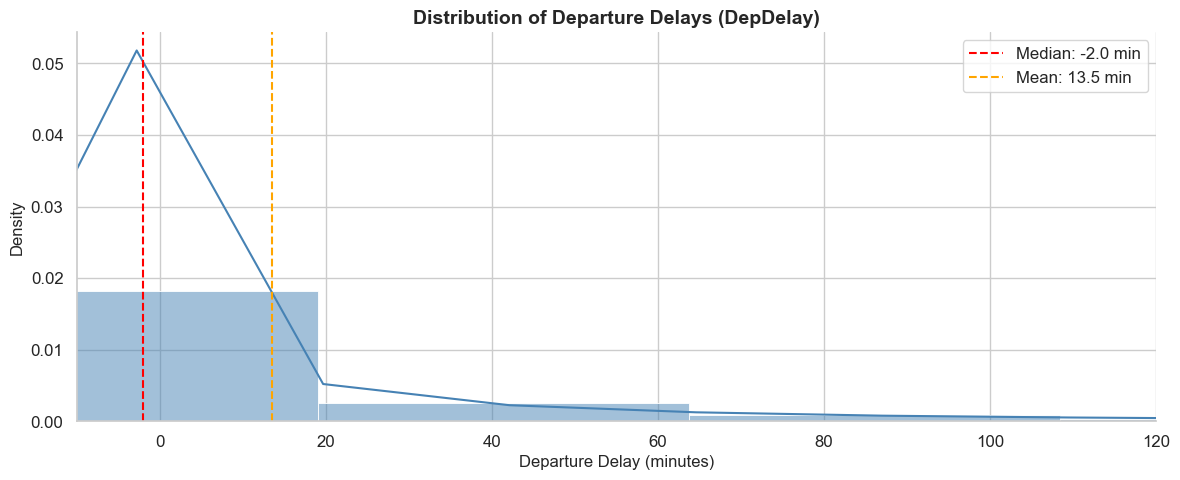

In [29]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(df_active['DepDelay'], bins=100, kde=True, ax=ax, color='steelblue', stat='density')
ax.set_title('Distribution of Departure Delays (DepDelay)', fontsize=14, fontweight='bold')
ax.set_xlabel('Departure Delay (minutes)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.axvline(df_active['DepDelay'].median(), color='red', linestyle='--', label=f"Median: {df_active['DepDelay'].median():.1f} min")
ax.axvline(df_active['DepDelay'].mean(), color='orange', linestyle='--', label=f"Mean: {df_active['DepDelay'].mean():.1f} min")
ax.legend()
ax.set_xlim(-10, 120)
plt.tight_layout()


**Observations:**
- The distribution is **heavily right-skewed** with a large peak near 0, indicating many flights depart on time.
- The median departure delay is much lower than the mean, confirming the long right tail of extreme delays.
- A substantial portion of flights have negative delays (departing early), which partially offsets late departures.
- The KDE shows a sharp peak at 0 and a long tail extending past 60 minutes — a classic delay distribution.


### V2: How are arrival delays distributed?

**Question:** How does the arrival delay distribution compare to departure delays?

**Visualization:** Histogram of ArrDelay with KDE overlay.


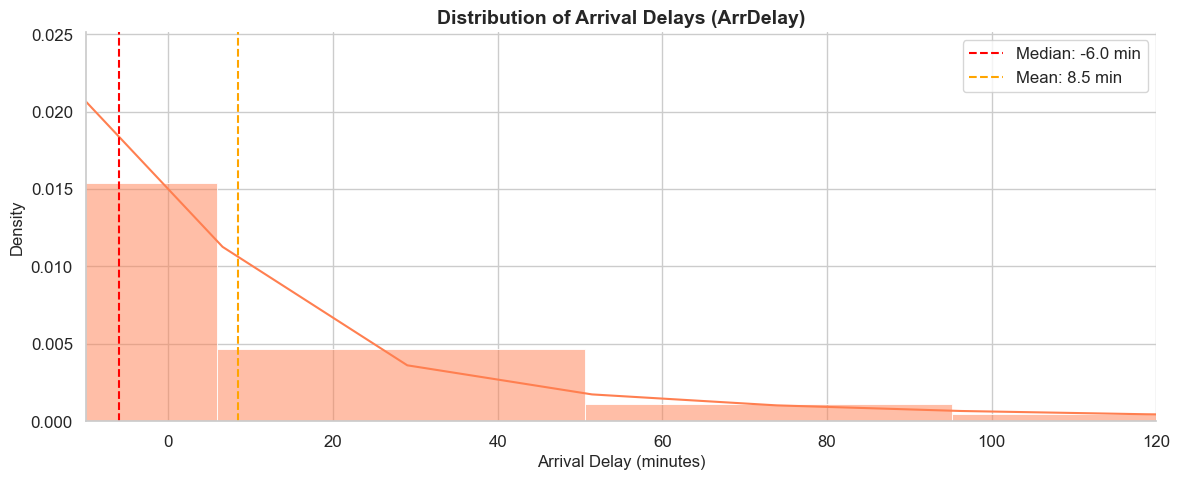

In [30]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(df_active['ArrDelay'], bins=100, kde=True, ax=ax, color='coral', stat='density')
ax.set_title('Distribution of Arrival Delays (ArrDelay)', fontsize=14, fontweight='bold')
ax.set_xlabel('Arrival Delay (minutes)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.axvline(df_active['ArrDelay'].median(), color='red', linestyle='--', label=f"Median: {df_active['ArrDelay'].median():.1f} min")
ax.axvline(df_active['ArrDelay'].mean(), color='orange', linestyle='--', label=f"Mean: {df_active['ArrDelay'].mean():.1f} min")
ax.legend()
ax.set_xlim(-10, 120)
plt.tight_layout()


**Observations:**
- Arrival delays show a similar right-skewed pattern but with a **wider spread** than departure delays.
- The mean arrival delay is higher than the mean departure delay, suggesting delays tend to **accumulate** over the flight.
- The peak near 0 is slightly less pronounced than for departure delays, indicating fewer perfectly-on-time arrivals.
- The tail extends further, with more extreme late arrivals.


### V3: How do departure and arrival delay distributions compare?

**Question:** Which is worse — departure delays or arrival delays? How do the distributions differ?

**Visualization:** Overlaid density plots of DepDelay and ArrDelay.


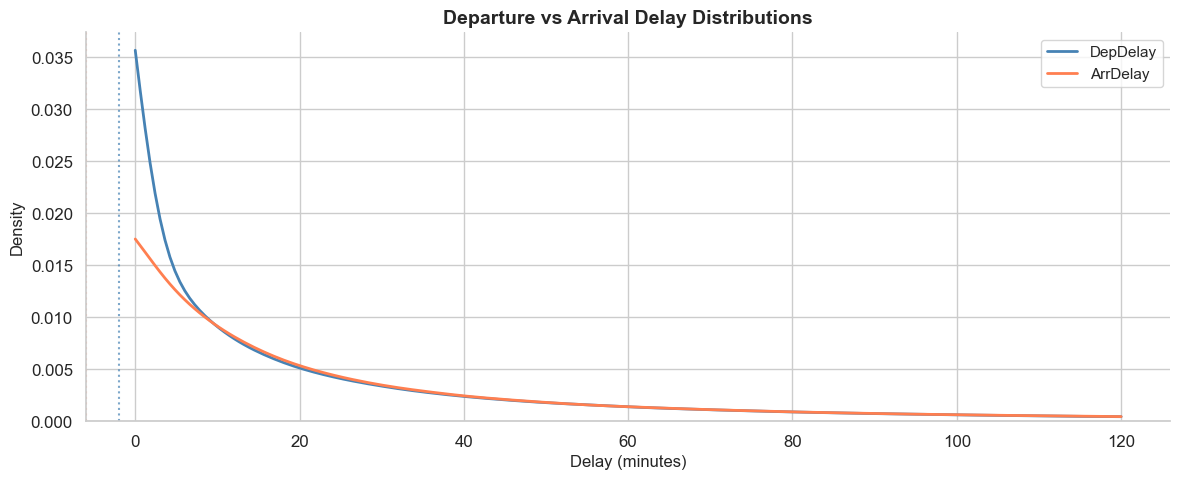

In [31]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.kdeplot(df_active['DepDelay'], ax=ax, color='steelblue', label='DepDelay', linewidth=2, clip=(0, 120))
sns.kdeplot(df_active['ArrDelay'], ax=ax, color='coral', label='ArrDelay', linewidth=2, clip=(0, 120))
ax.set_title('Departure vs Arrival Delay Distributions', fontsize=14, fontweight='bold')
ax.set_xlabel('Delay (minutes)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=11)
ax.axvline(df_active['DepDelay'].median(), color='steelblue', linestyle=':', alpha=0.7)
ax.axvline(df_active['ArrDelay'].median(), color='coral', linestyle=':', alpha=0.7)
plt.tight_layout()


**Observations:**
- **Arrival delays are consistently worse** than departure delays across the entire distribution.
- The ArrDelay density curve is shifted to the right, confirming that flights tend to arrive later relative to schedule than they departed.
- The ArrDelay distribution has a **wider spread** — more extreme late arrivals.
- The gap between the two curves widens in the 20-60 minute range, where delays accumulate most significantly.


### V4: What is the distribution of flight distance?

**Question:** How are flights distributed across short-haul, medium-haul, and long-haul distances?

**Visualization:** Histogram of Distance.


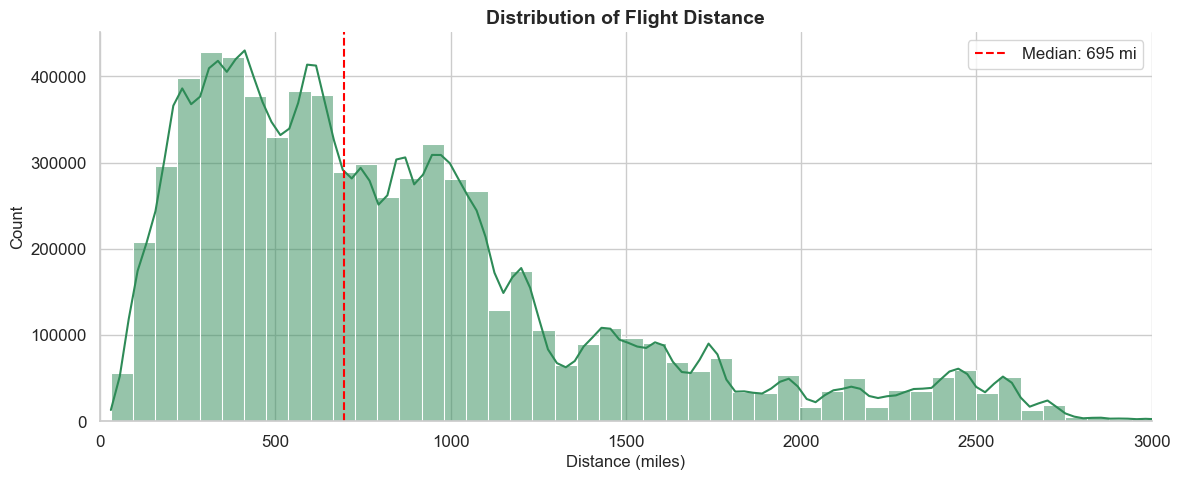

In [32]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(df_active['Distance'], bins=80, kde=True, ax=ax, color='seagreen')
ax.set_title('Distribution of Flight Distance', fontsize=14, fontweight='bold')
ax.set_xlabel('Distance (miles)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.axvline(df_active['Distance'].median(), color='red', linestyle='--', label=f"Median: {df_active['Distance'].median():.0f} mi")
ax.legend()
ax.set_xlim(0, 3000)
plt.tight_layout()


**Observations:**
- Distance is **right-skewed** with a peak at shorter distances (100-500 miles), reflecting the high volume of domestic short-haul flights.
- There appears to be a **secondary peak** around 1,500-2,000 miles, suggesting a bimodal pattern (short regional flights vs. cross-country routes).
- Very few flights exceed 2,500 miles, which makes sense for a US domestic dataset.


### V5: How are delay causes distributed?

**Question:** What are the primary causes of flight delays? Which delay category contributes the most?

**Visualization:** Bar chart of mean delay by cause.


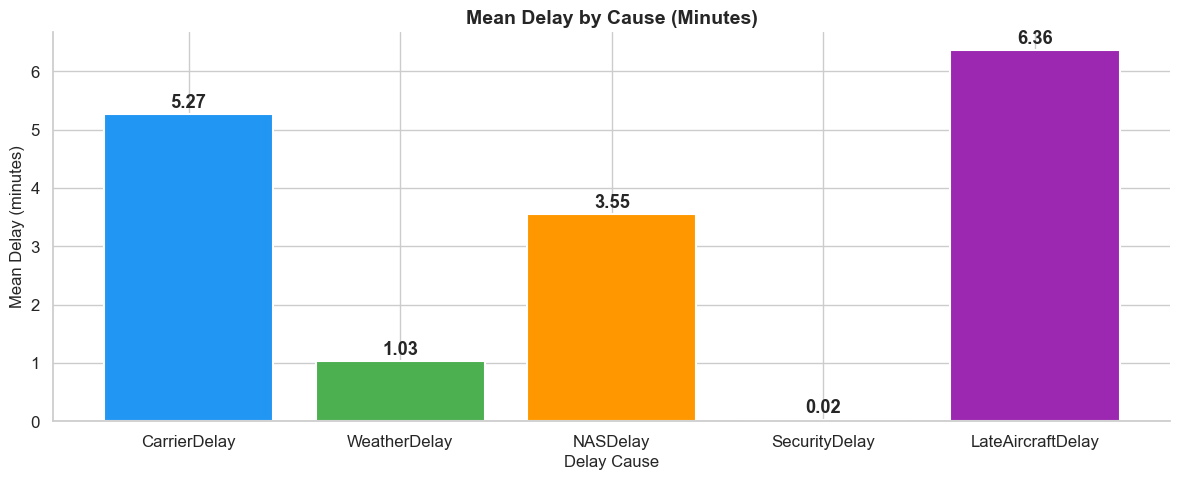

In [33]:
delay_causes = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']
cause_means = df_active[delay_causes].mean()

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']
bars = ax.bar(cause_means.index, cause_means.values, color=colors, edgecolor='white', linewidth=1.5)
ax.set_title('Mean Delay by Cause (Minutes)', fontsize=14, fontweight='bold')
ax.set_xlabel('Delay Cause', fontsize=12)
ax.set_ylabel('Mean Delay (minutes)', fontsize=12)
for bar, val in zip(bars, cause_means.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()


**Observations:**
- **LateAircraftDelay** is the largest contributor to delays, reflecting the cascading effect of late-arriving aircraft causing subsequent departures to be delayed.
- **CarrierDelay** (airline operational issues like crew scheduling, maintenance) is the second-largest cause.
- **NASDelay** (National Air System congestion) is significant, reflecting air traffic control constraints.
- **WeatherDelay** and **SecurityDelay** are relatively minor contributors on average, though weather can be highly variable by season and region.


### V6: What proportion of flights are cancelled or diverted?

**Question:** How common are flight cancellations and diversions?

**Visualization:** Count plot of cancellation and diversion status.


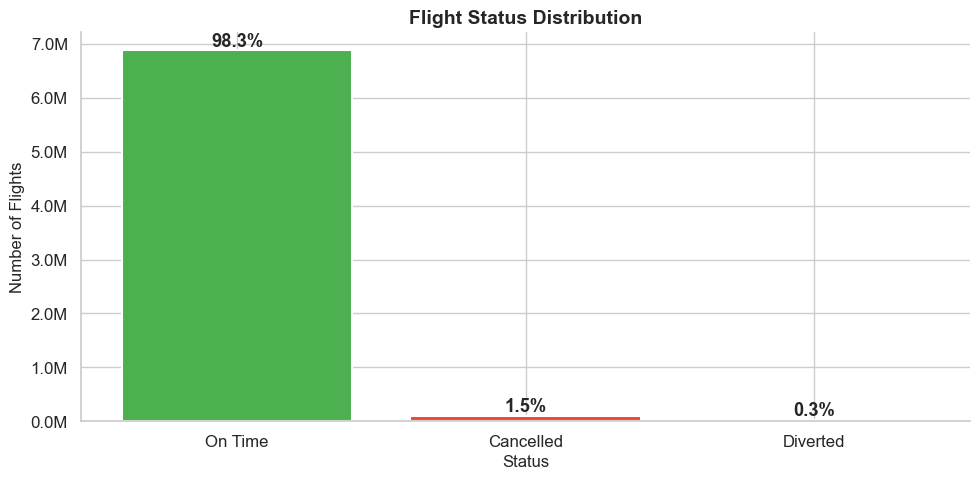

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))
on_time = len(df) - df['Cancelled'].sum() - df['Diverted'].sum()
status_counts = pd.DataFrame({
    'Status': ['On Time', 'Cancelled', 'Diverted'],
    'Count': [on_time, df['Cancelled'].sum(), df['Diverted'].sum()]
})
bars = ax.bar(status_counts['Status'], status_counts['Count'], color=['#4CAF50', '#F44336', '#FF9800'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, status_counts['Count']):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5000,
            f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.set_title('Flight Status Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Flights', fontsize=12)
ax.set_xlabel('Status', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()


**Observations:**
- The vast majority of flights operate on time (not cancelled or diverted).
- The cancellation rate is relatively low, but the absolute number is significant given the 7M flight sample.
- Diversions are rare, typically triggered by weather or mechanical issues at the destination.


## Step 3: Bivariate Exploration

Assumption: comparing pairs of variables will show whether delays are mostly explained by departure behavior, airline operations, time patterns, geography, or distance.

Questions for this section:
- How strongly do departure and arrival delays move together?
- Which airlines, days, months, and states show different delay behavior?
- Are distance and delay causes meaningful explanatory features?

Investigating relationships between pairs of variables.


### V7: How do departure delays relate to arrival delays?

**Question:** Do late departures always lead to late arrivals? What is the strength of this relationship?

**Visualization:** Hexbin plot of DepDelay vs ArrDelay (subsampled to handle 7M+ rows).


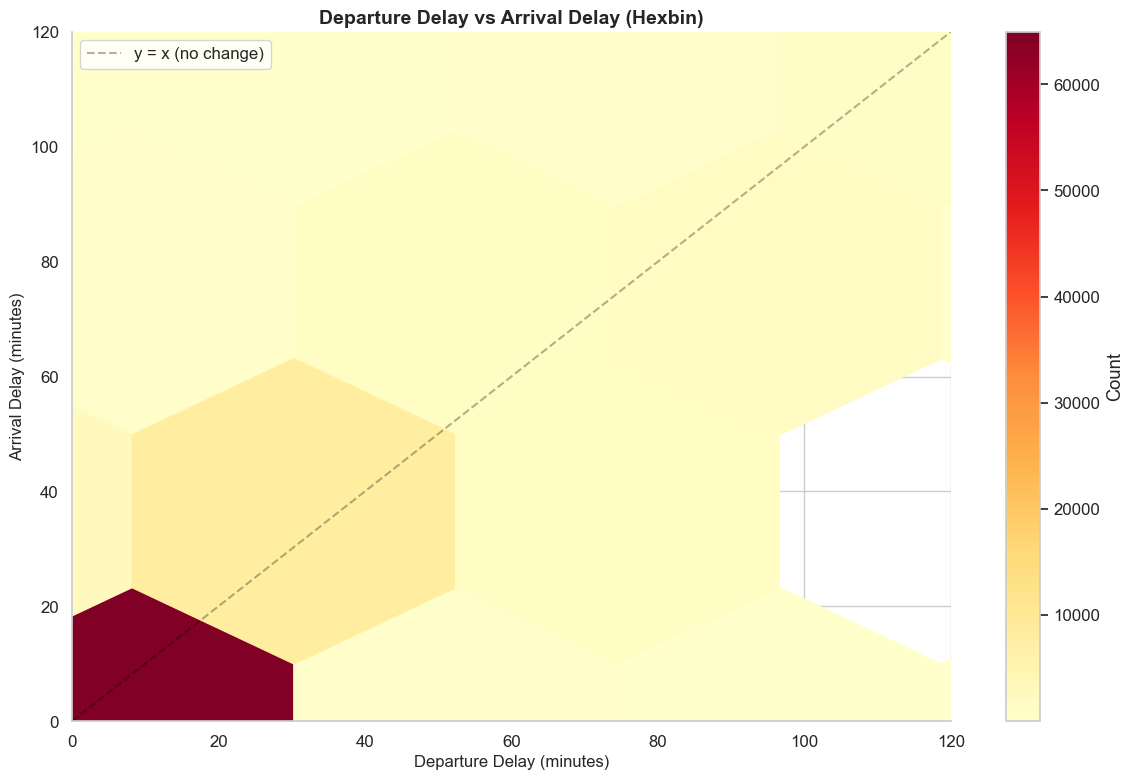

In [35]:
# Subsample for hexbin to avoid performance issues
sample = df_active.sample(n=100000, random_state=42)

fig, ax = plt.subplots(figsize=(12, 8))
hb = ax.hexbin(sample['DepDelay'], sample['ArrDelay'], gridsize=40, cmap='YlOrRd', mincnt=1)
ax.set_title('Departure Delay vs Arrival Delay (Hexbin)', fontsize=14, fontweight='bold')
ax.set_xlabel('Departure Delay (minutes)', fontsize=12)
ax.set_ylabel('Arrival Delay (minutes)', fontsize=12)
ax.set_xlim(0, 120)
ax.set_ylim(0, 120)
ax.plot([0, 120], [0, 120], 'k--', alpha=0.3, label='y = x (no change)')
plt.colorbar(hb, label='Count')
ax.legend()
plt.tight_layout()


**Observations:**
- There is a **strong positive correlation** between departure and arrival delays — late departures tend to arrive late.
- Most points lie **above the y=x line**, confirming that delays tend to **worsen** over the course of a flight.
- The relationship is not perfectly linear: some flights with large departure delays arrive with smaller delays (recovery en route), and vice versa.
- There is significant scatter, indicating that other factors (weather en route, air traffic at destination, etc.) also play important roles.


### V8: How do departure delays vary by airline?

**Question:** Which airlines have the worst departure on-time performance?

**Visualization:** Box plot of DepDelay grouped by airline (top 10 by volume).


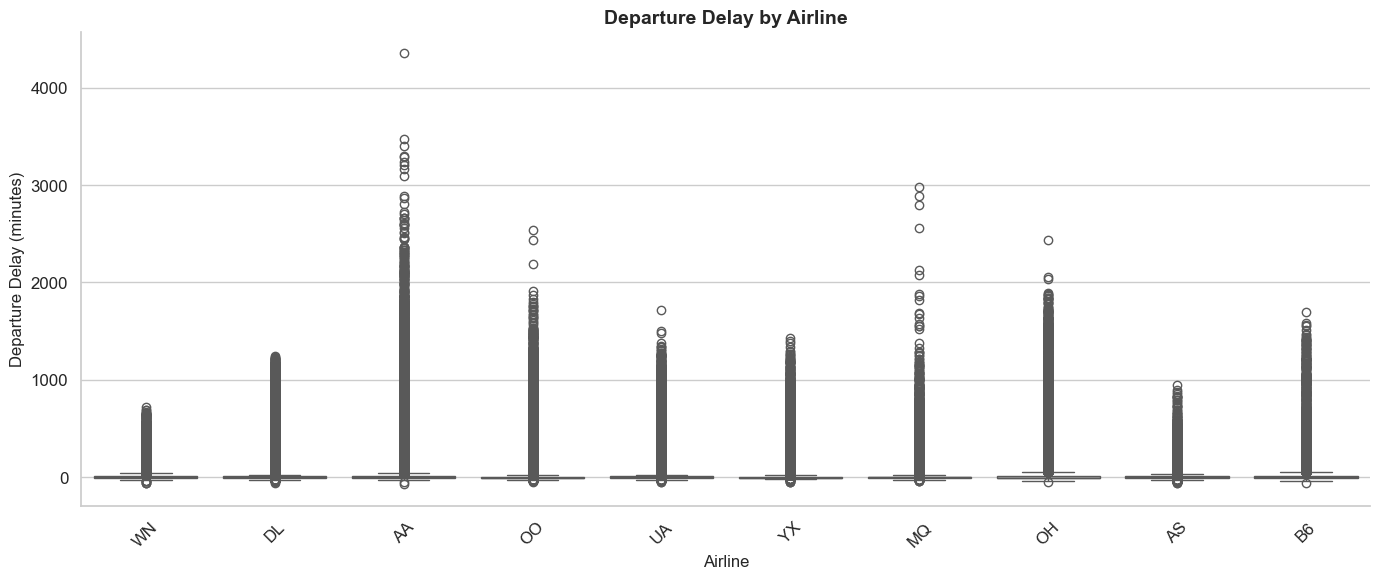

In [36]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df_active, x='AirlineGroup', y='DepDelay', ax=ax, palette='Set2', order=top_airlines)
ax.set_title('Departure Delay by Airline', fontsize=14, fontweight='bold')
ax.set_xlabel('Airline', fontsize=12)
ax.set_ylabel('Departure Delay (minutes)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()


**Observations:**
- There is **significant variation** in departure delays across airlines.
- Some airlines show higher median delays and wider interquartile ranges, suggesting systemic operational challenges.
- The 'Other' category (smaller airlines) shows high variability, likely reflecting diverse operational profiles.
- Outliers (individual points beyond whiskers) are common across all airlines, indicating occasional extreme delays.


### V9: How do arrival delays vary by airline?

**Question:** Which airlines have the worst arrival on-time performance? How does this compare to departure performance?

**Visualization:** Box plot of ArrDelay grouped by airline.


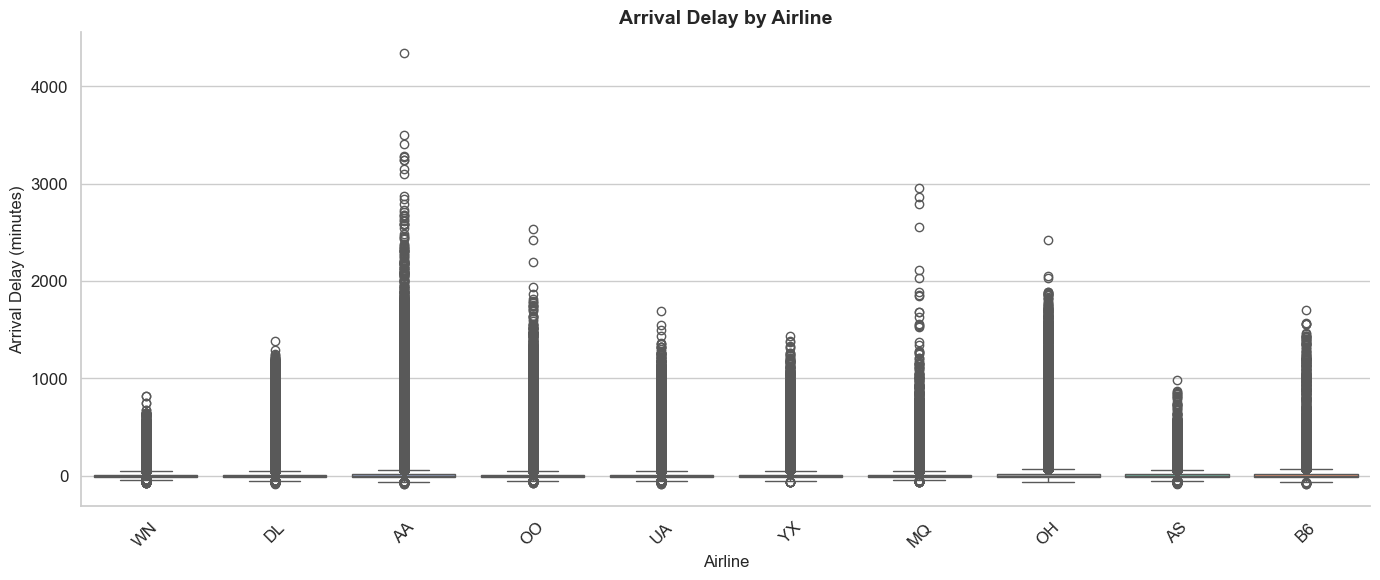

In [37]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df_active, x='AirlineGroup', y='ArrDelay', ax=ax, palette='Set2', order=top_airlines)
ax.set_title('Arrival Delay by Airline', fontsize=14, fontweight='bold')
ax.set_xlabel('Airline', fontsize=12)
ax.set_ylabel('Arrival Delay (minutes)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()


**Observations:**
- The airline ranking for arrival delays is **similar but not identical** to departure delays.
- Airlines with poor departure performance tend to also have poor arrival performance, but the gap varies.
- Some airlines show a larger gap between departure and arrival box plots, suggesting they lose more time en route.
- The 'Other' category again shows high variability in arrival delays.


### V10: How do delays vary by day of the week?

**Question:** Are certain days of the week associated with more delays?

**Visualization:** Box plot of ArrDelay by DayOfWeek.


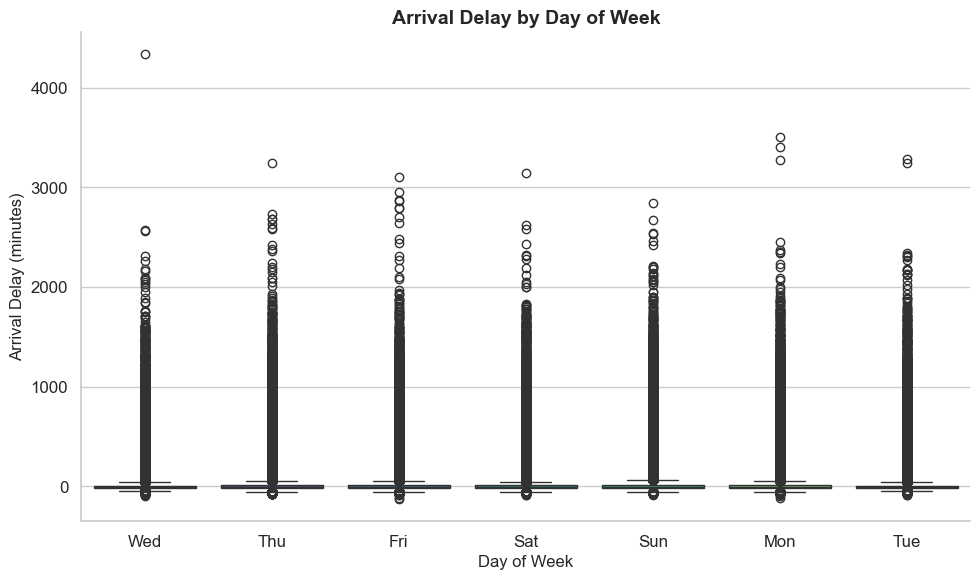

In [38]:
day_names = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
df_active['DayName'] = df_active['DayOfWeek'].map(day_names)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_active, x='DayName', y='ArrDelay', ax=ax, palette='viridis')
ax.set_title('Arrival Delay by Day of Week', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Arrival Delay (minutes)', fontsize=12)
plt.tight_layout()


**Observations:**
- **Friday** tends to have the highest median arrival delays, consistent with the end-of-week travel rush and accumulated operational fatigue.
- **Monday** also shows elevated delays, possibly due to weekend maintenance backlogs and repositioning flights.
- **Mid-week (Tue-Thu)** shows relatively lower delays.
- **Saturday** shows lower median delays but higher variability (fewer flights, more charter/leisure traffic).


### V11: How do delays vary by month?

**Question:** Are there seasonal patterns in flight delays?

**Visualization:** Box plot of ArrDelay by Month.


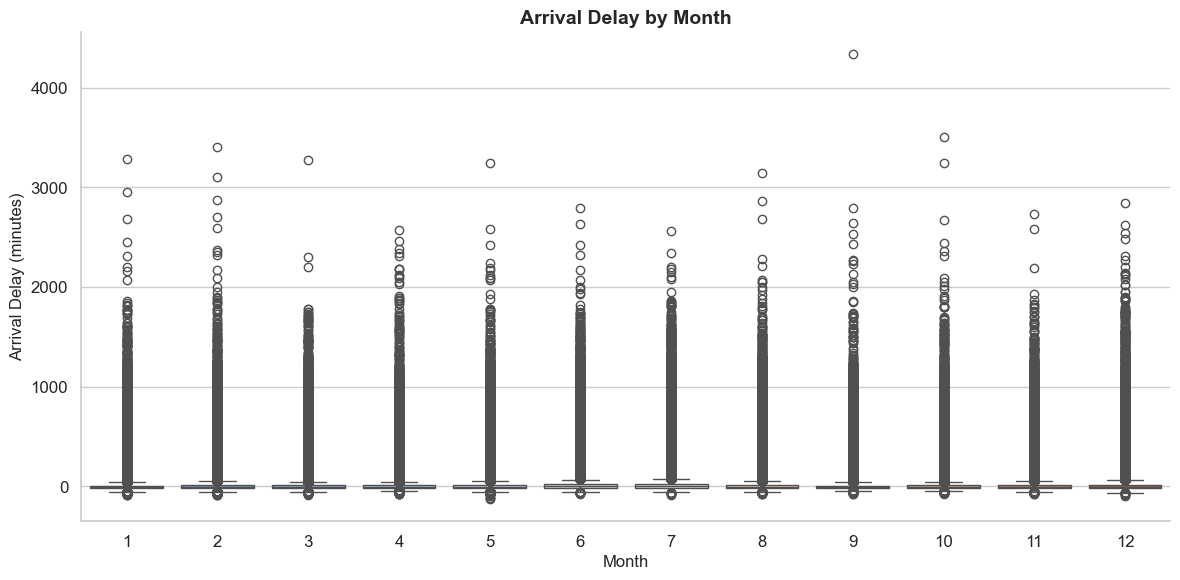

In [39]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_active, x='Month', y='ArrDelay', ax=ax, palette='coolwarm')
ax.set_title('Arrival Delay by Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Arrival Delay (minutes)', fontsize=12)
plt.tight_layout()


**Observations:**
- **Winter months (Dec, Jan, Feb)** show elevated delays, likely due to weather (snow, ice, fog).
- **Summer months (Jun-Aug)** also show higher delays, possibly due to thunderstorm season and peak travel volume.
- **Spring (Mar-May)** and **Fall (Sep-Nov)** tend to have lower median delays.
- The pattern suggests **bimodal seasonality** — weather in winter and volume/weather in summer.


### V12: How does flight distance relate to delay?

**Question:** Do longer flights experience more or less delay than shorter flights?

**Visualization:** Hexbin plot of Distance vs ArrDelay (subsampled).


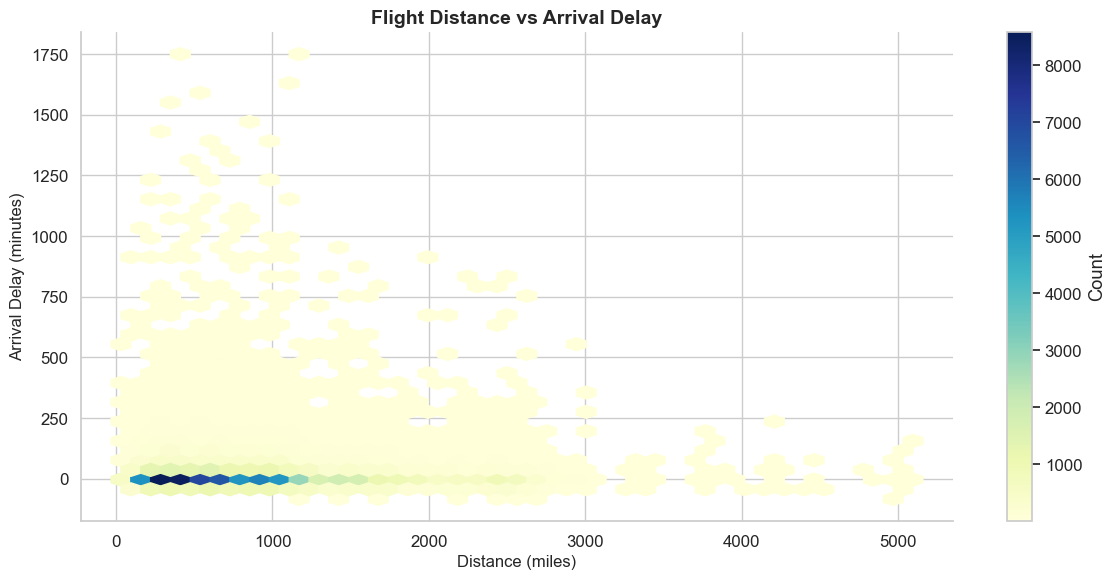

In [40]:
fig, ax = plt.subplots(figsize=(12, 6))
hb = ax.hexbin(sample['Distance'], sample['ArrDelay'], gridsize=40, cmap='YlGnBu', mincnt=1)
ax.set_title('Flight Distance vs Arrival Delay', fontsize=14, fontweight='bold')
ax.set_xlabel('Distance (miles)', fontsize=12)
ax.set_ylabel('Arrival Delay (minutes)', fontsize=12)
plt.colorbar(hb, label='Count')
plt.tight_layout()


**Observations:**
- There is a **weak positive relationship** between distance and arrival delay — longer flights tend to have slightly higher delays.
- However, the relationship is **noisy**, indicating that distance alone is not a strong predictor of delay.
- Short flights (< 500 miles) show a wide range of delays, suggesting that local factors (airport congestion, weather) matter more than distance for short hops.
- Very long flights (> 2,500 miles) are rare but tend to have moderate delays.


### V13: How do delay causes vary by airline?

**Question:** Do different airlines experience different types of delays?

**Visualization:** Clustered bar chart of mean delay by cause, grouped by airline.


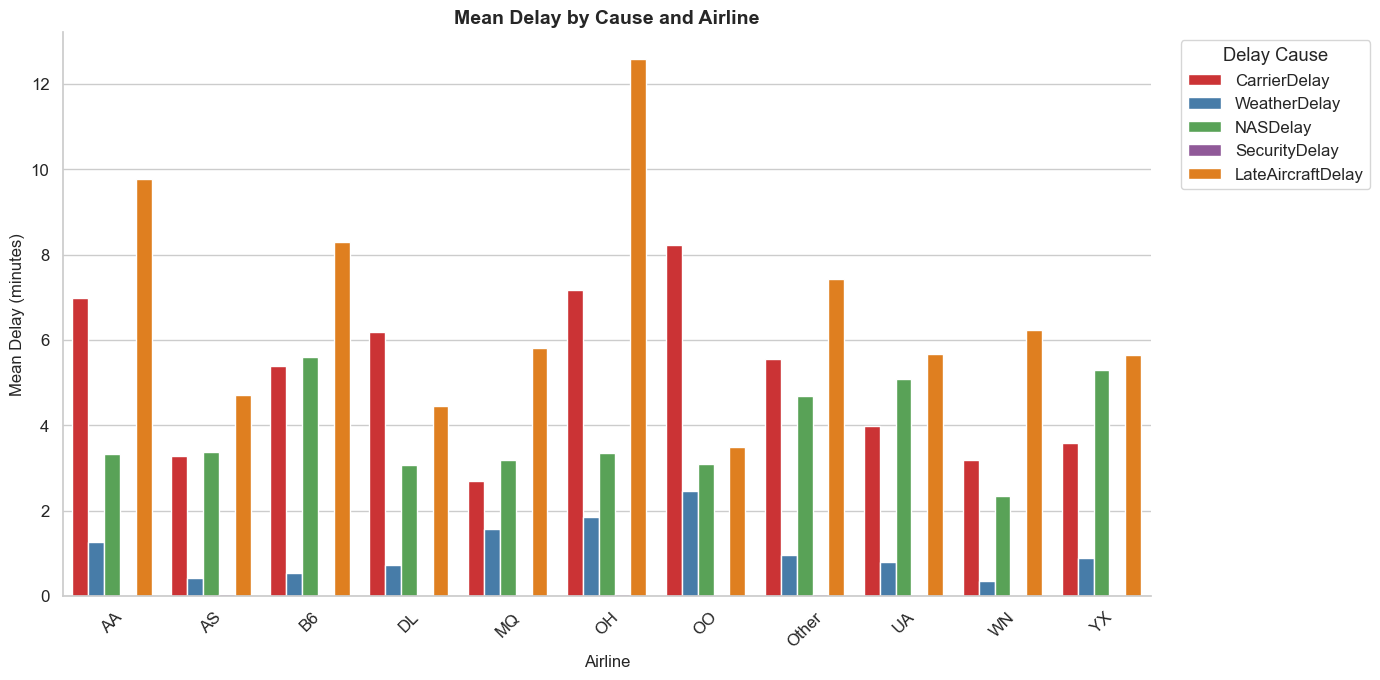

In [41]:
cause_by_airline = df_active.groupby('AirlineGroup')[delay_causes].mean()
cause_long = cause_by_airline.stack().reset_index()
cause_long.columns = ['AirlineGroup', 'Cause', 'MeanDelay']

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(data=cause_long, x='AirlineGroup', y='MeanDelay', hue='Cause', ax=ax, palette='Set1')
ax.set_title('Mean Delay by Cause and Airline', fontsize=14, fontweight='bold')
ax.set_xlabel('Airline', fontsize=12)
ax.set_ylabel('Mean Delay (minutes)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Delay Cause', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()


**Observations:**
- **LateAircraftDelay** is the dominant cause across most airlines, reflecting the cascading nature of delays in airline operations.
- **CarrierDelay** varies significantly by airline — some airlines have more operational issues (crew, maintenance) than others.
- **WeatherDelay** is relatively uniform across airlines (weather affects everyone), but some airlines in weather-prone hubs may show higher values.
- **NASDelay** (air traffic control) varies by airline, likely reflecting differences in route networks and hub locations.


## Step 4: Multivariate Exploration

Assumption: meaningful delay patterns depend on interacting factors, such as day plus time of day, airline plus distance, or departure delay plus en-route recovery.

Questions for this section:
- Which relationships remain visible when a third variable is added?
- Do some contexts compound delays while others recover them?
- Which multivariate findings are strong enough to polish for the explanatory notebook?

Investigating relationships among three or more variables.


### V14: How do delays vary by time of day AND day of week?

**Question:** Are there specific day/time combinations that experience more delays?

**Visualization:** FacetGrid of mean delay by DayOfWeek, faceted by TimeOfDay.


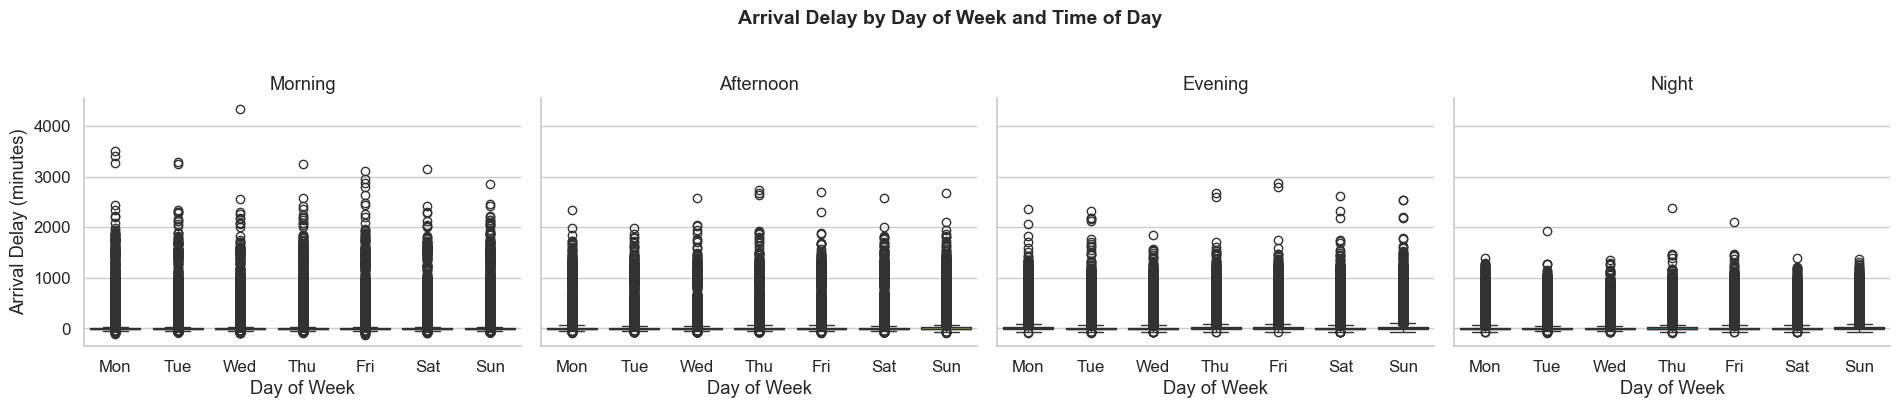

In [42]:
g = sns.FacetGrid(df_active, col='TimeOfDay', col_order=['Morning', 'Afternoon', 'Evening', 'Night'],
                  height=4, aspect=1.2)
g.map_dataframe(sns.boxplot, x='DayName', y='ArrDelay', palette='viridis', order=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
g.set_axis_labels('Day of Week', 'Arrival Delay (minutes)')
g.set_titles('{col_name}')
g.fig.suptitle('Arrival Delay by Day of Week and Time of Day', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()


**Observations:**
- **Evening flights on Friday** show the highest delays, combining end-of-week traffic with late-day operational fatigue.
- **Morning flights** tend to have lower delays, possibly because airlines build in buffer time to recover from overnight disruptions.
- **Night flights** show the lowest delays but also the fewest flights.
- The **Afternoon** shows moderate delays, with a gradual increase toward Friday.


### V15: How do departure and arrival delays vary by origin state?

**Question:** Do some states consistently delay departures but recover en route? Do some only delay arrivals?

**Visualization:** Clustered bar chart of mean DepDelay and ArrDelay by OriginState (top 15 states).


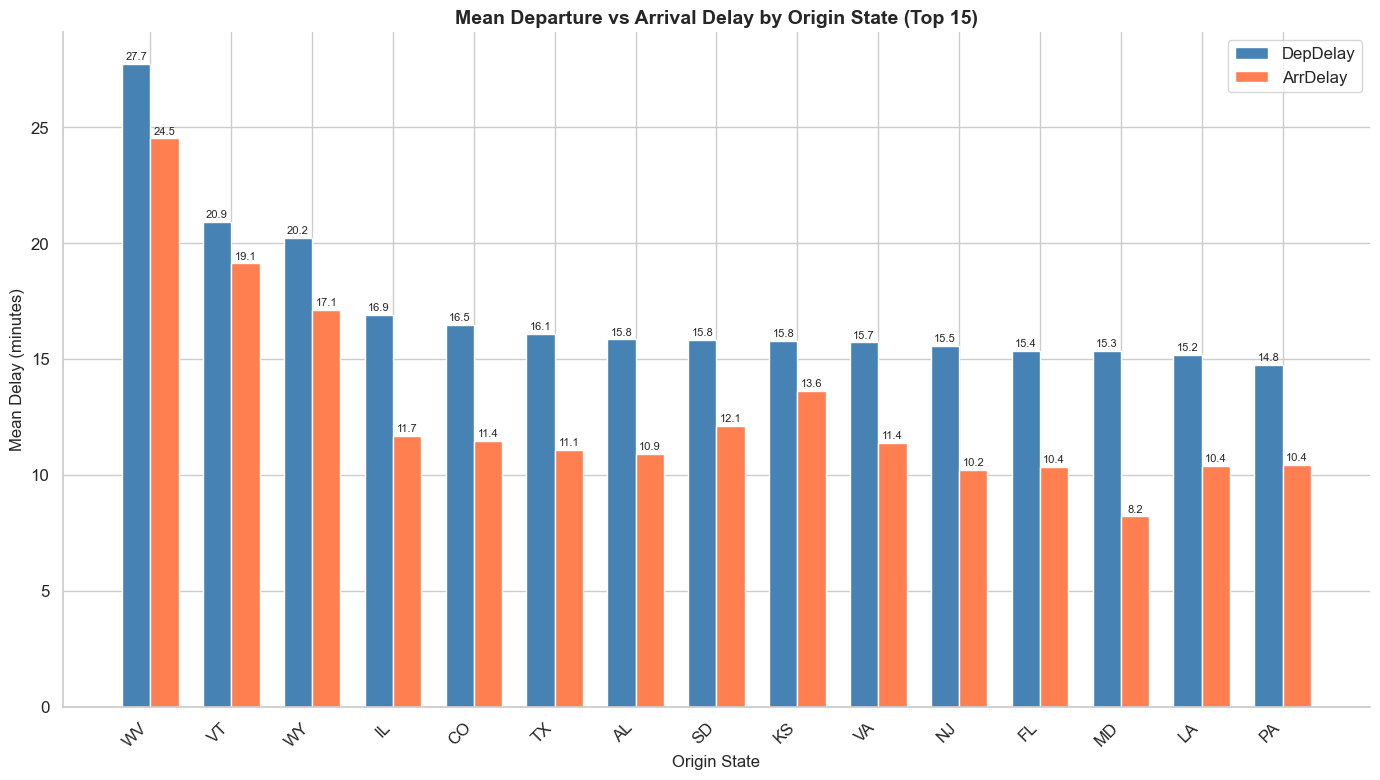

In [43]:
state_delays = df_active.groupby('OriginState').agg({
    'DepDelay': 'mean',
    'ArrDelay': 'mean'
}).sort_values('DepDelay', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(state_delays))
width = 0.35
bars1 = ax.bar(x - width/2, state_delays['DepDelay'], width, label='DepDelay', color='steelblue')
bars2 = ax.bar(x + width/2, state_delays['ArrDelay'], width, label='ArrDelay', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(state_delays.index, rotation=45, ha='right')
ax.set_title('Mean Departure vs Arrival Delay by Origin State (Top 15)', fontsize=14, fontweight='bold')
ax.set_xlabel('Origin State', fontsize=12)
ax.set_ylabel('Mean Delay (minutes)', fontsize=12)
ax.legend()
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()


**Observations:**
- Some states (e.g., **NY, FL, IL**) show high departure delays, likely due to major hub airports (JFK, LGA, EWR, MIA, ORD) experiencing congestion.
- The gap between DepDelay and ArrDelay varies by state — some states show larger gaps, meaning delays **worsen en route** from those origins.
- States with lower departure delays but higher arrival delays may indicate that the issue is at the **destination** rather than the origin.
- This visualization helps identify whether delay problems are **origin-focused** (airport/airline operations) or **route-focused** (en route conditions).


### V16: How do multiple encodings reveal departure vs arrival patterns?

**Question:** Can we see how airline, distance, and delay interact simultaneously?

**Visualization:** Scatter plot with color=airline, size=distance, x=DepDelay, y=ArrDelay.


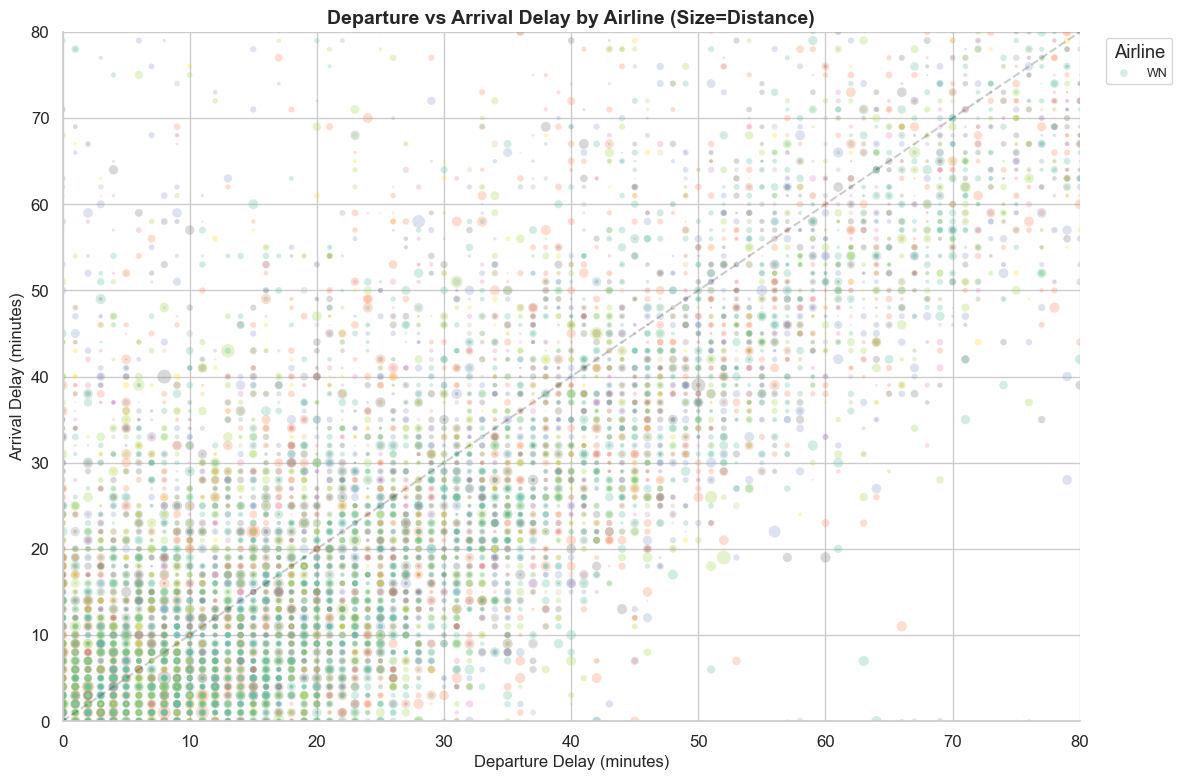

In [44]:
# Subsample for readability
sample2 = df_active.sample(n=50000, random_state=42)

fig, ax = plt.subplots(figsize=(12, 8))
palette = sns.color_palette('Set2', len(top_airlines))
airline_colors = {air: palette[i] for i, air in enumerate(top_airlines)}
airline_colors['Other'] = 'gray'

for airline, group in sample2.groupby('AirlineGroup'):
    ax.scatter(group['DepDelay'], group['ArrDelay'],
               c=[airline_colors.get(airline, 'gray')],
               s=group['Distance'] / 50,
               alpha=0.3, label=airline if airline == top_airlines[0] else '', edgecolors='none')

ax.set_title('Departure vs Arrival Delay by Airline (Size=Distance)', fontsize=14, fontweight='bold')
ax.set_xlabel('Departure Delay (minutes)', fontsize=12)
ax.set_ylabel('Arrival Delay (minutes)', fontsize=12)
ax.set_xlim(0, 80)
ax.set_ylim(0, 80)
ax.plot([0, 80], [0, 80], 'k--', alpha=0.2)
ax.legend(title='Airline', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()


**Observations:**
- The scatter reveals that **larger flights (longer distance)** tend to have slightly higher delays, visible as larger dots clustering higher.
- Different airlines show **distinct clusters** — some consistently above the y=x line (worsening delays), others closer to it.
- The size encoding (distance) adds a third dimension: short flights cluster near the origin, while long flights spread further out.
- This multi-encoding view helps identify which airlines have systemic delay issues across all route lengths.


### V17: Do delays compound or dissipate over the course of a flight?

**Question:** Do late flights get worse or better over the course of the flight?

**Visualization:** Scatter plot of DelayDelta (ArrDelay - DepDelay) vs DepDelay, with box plot inset.


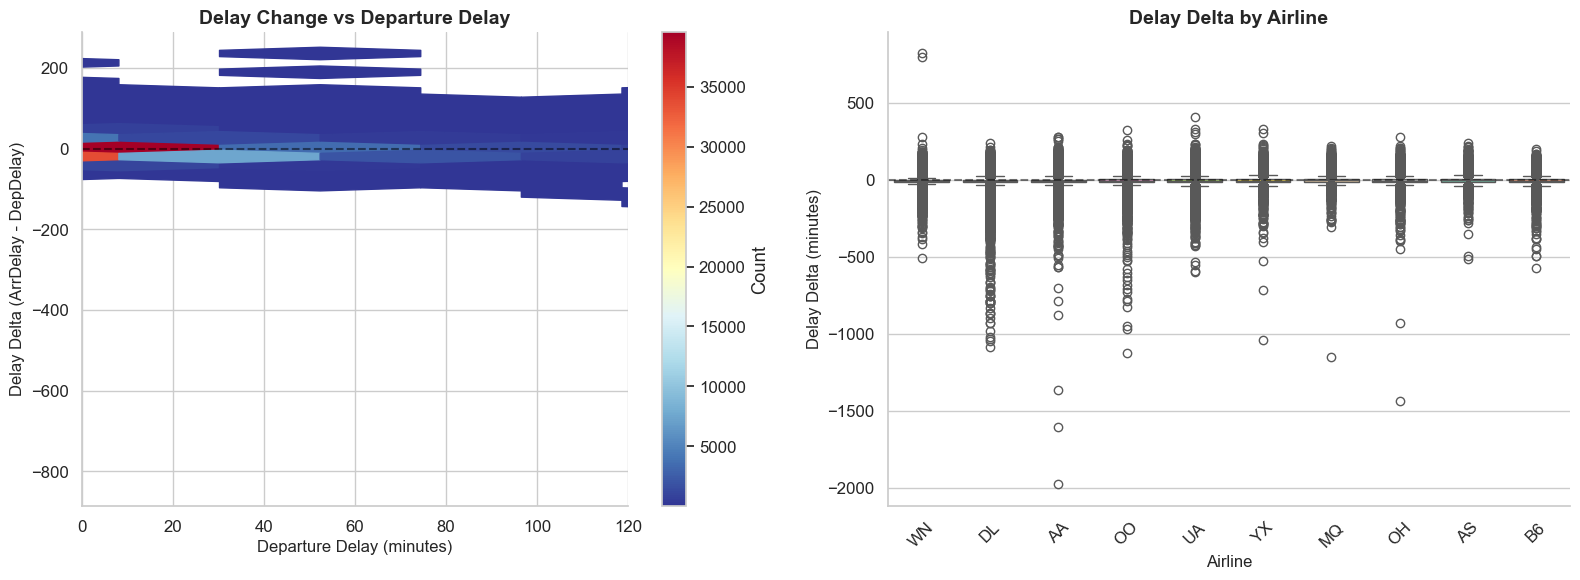

In [45]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Scatter of DelayDelta vs DepDelay
hb = ax1.hexbin(sample['DepDelay'], sample['DelayDelta'], gridsize=40, cmap='RdYlBu_r', mincnt=1)
ax1.axhline(0, color='black', linestyle='--', alpha=0.5)
ax1.set_title('Delay Change vs Departure Delay', fontsize=14, fontweight='bold')
ax1.set_xlabel('Departure Delay (minutes)', fontsize=12)
ax1.set_ylabel('Delay Delta (ArrDelay - DepDelay)', fontsize=12)
ax1.set_xlim(0, 120)
plt.colorbar(hb, ax=ax1, label='Count')

# Right: Box plot of DelayDelta by airline
sns.boxplot(data=df_active, x='AirlineGroup', y='DelayDelta', ax=ax2, palette='Set2', order=top_airlines)
ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
ax2.set_title('Delay Delta by Airline', fontsize=14, fontweight='bold')
ax2.set_xlabel('Airline', fontsize=12)
ax2.set_ylabel('Delay Delta (minutes)', fontsize=12)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()


**Observations:**
- **Most flights have a positive delay delta** (ArrDelay > DepDelay), meaning delays tend to **compound** over the course of a flight.
- The scatter plot shows that flights with larger departure delays tend to have **larger positive deltas** — late flights get worse.
- However, there is a **cluster of points below the zero line**, indicating some flights recover delay en route (possibly due to catching up time or favorable tailwinds).
- The airline box plot shows that some airlines have **median delay deltas closer to zero**, suggesting better en-route recovery capabilities.


### V18: Plot matrix of key numeric variables

**Question:** What is the correlation structure across all key numeric variables?

**Visualization:** Pair plot (scatter matrix) of DepDelay, ArrDelay, Distance, ActualElapsedTime.


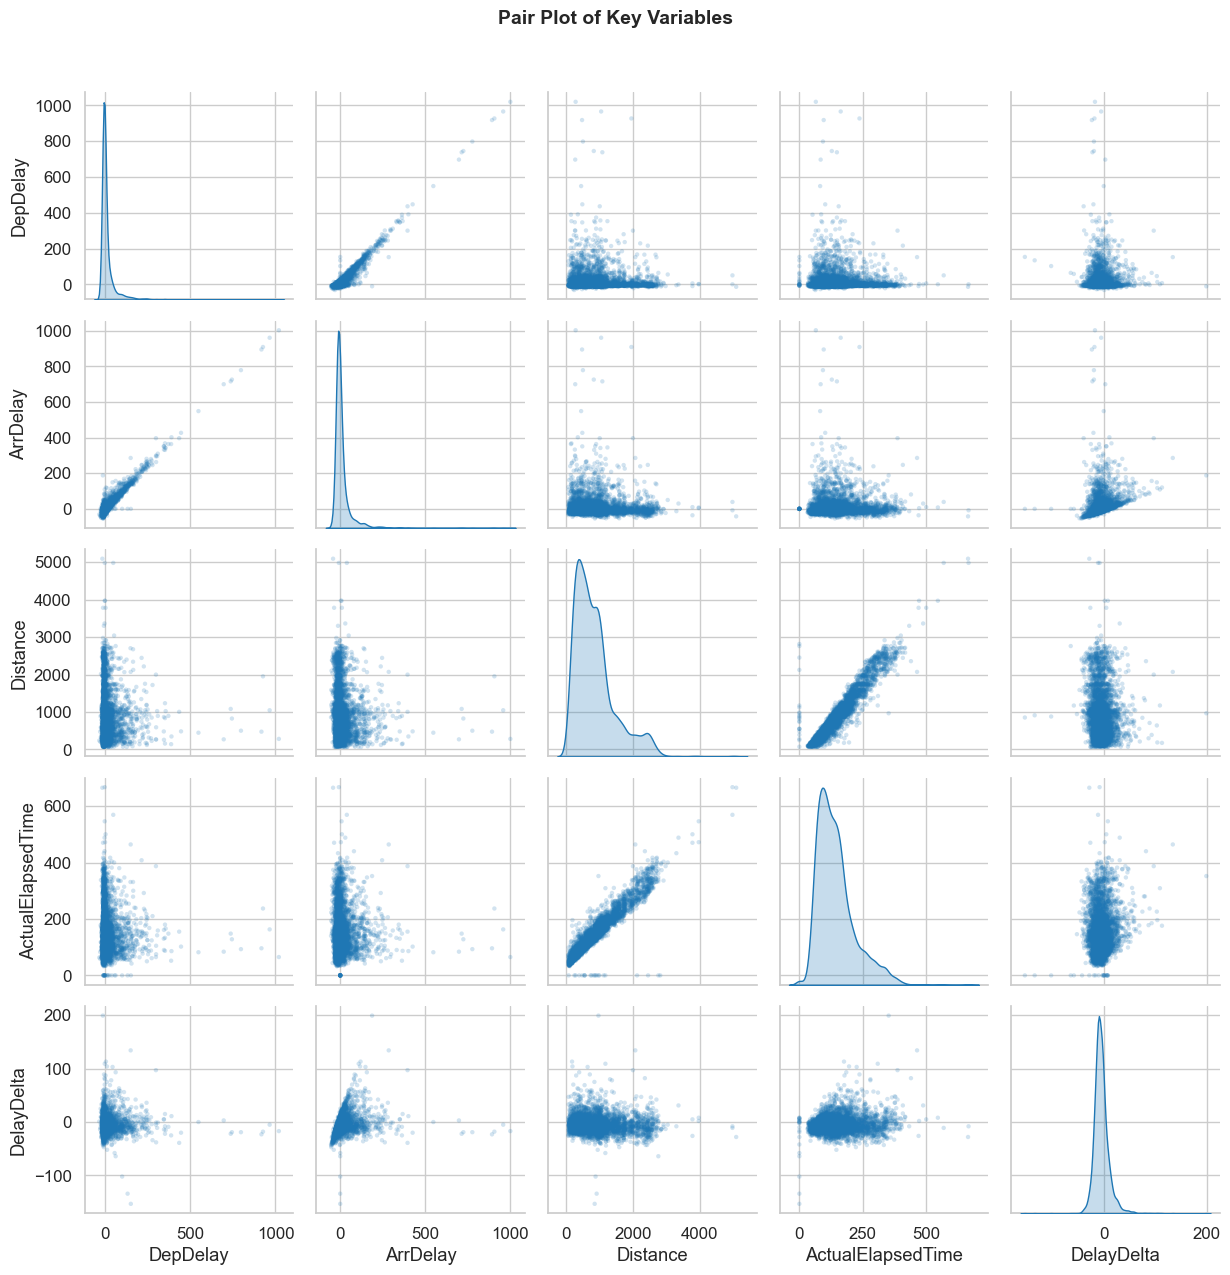

In [46]:
plot_cols = ['DepDelay', 'ArrDelay', 'Distance', 'ActualElapsedTime', 'DelayDelta']
plot_sample = df_active[plot_cols].sample(n=5000, random_state=42)

g = sns.pairplot(plot_sample, diag_kind='kde', plot_kws={'alpha': 0.2, 's': 10, 'edgecolor': 'none'})
g.fig.suptitle('Pair Plot of Key Variables', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()


**Observations:**
- **DepDelay and ArrDelay** show a strong positive correlation (upper-right scatter), confirming the relationship seen in V7.
- **Distance and ActualElapsedTime** are strongly correlated (as expected — longer flights take more time).
- **DelayDelta** shows a weak positive correlation with DepDelay — late departures tend to get worse.
- The diagonal KDEs confirm the right-skewed distributions of delay variables and the more symmetric distribution of Distance.


## Conclusions

### Summary of Main Findings

1. **Delays compound over the flight:** The median delay delta (ArrDelay - DepDelay) is positive, meaning flights tend to arrive later relative to schedule than they departed. Late departures are particularly prone to worsening en route.

2. **Airline operations are the dominant delay driver:** LateAircraftDelay and CarrierDelay are the largest contributors to overall delays. This suggests that airline operational efficiency (crew scheduling, aircraft turnaround, maintenance) is more impactful than weather or air traffic control.

3. **Friday is the worst day:** Both departure and arrival delays peak on Fridays, likely due to accumulated operational fatigue and end-of-week travel volume.

4. **Seasonal bimodality:** Delays are elevated in both winter (weather) and summer (thunderstorms + volume), with spring and fall showing the best on-time performance.

5. **Hub states drive congestion:** States with major hub airports show consistently higher delays, but the gap between departure and arrival delays varies — some hubs recover en route while others worsen.

6. **Distance is a weak predictor:** While longer flights tend to have slightly higher delays, the relationship is noisy. Local factors (airport congestion, weather) matter more than distance.

### Reflections

- **NaN handling was critical:** Treating NaN delays as 0 (on-time) rather than missing data was essential for correct analysis.
- **Subsampling was necessary:** With 7M+ flights, hexbin plots and pair plots required subsampling to maintain performance.
- **The departure/arrival comparison framing** revealed insights that a single-delay analysis would miss — particularly how delays accumulate and which airlines recover best en route.

### Dead Ends and Unexpected Findings

- **SecurityDelay was negligible:** Security delay contribution is minimal in modern data.
- **Cancellation analysis was limited:** Cancelled flights have NaN delays, so they were excluded from delay analysis. A separate analysis of cancellation predictors would be valuable for Part II.
- **Route-level analysis was not pursued:** Origin-Dest pairs would reveal route-specific patterns but would require significant additional computation.


## Export

To export this notebook as HTML, run:

```bash
jupyter nbconvert Part_I_exploration.ipynb --to html
```
